\newpage

\tableofcontents

\newpage

# ***Digitalización de las gráficas y obtención de $E_{gap}$ para el $c-Si$***

## ***Imports necesarios***

In [1]:
# Importar NumPy para operaciones matriciales y numéricas
import numpy as np

# Importar Matplotlib para crear gráficas y visualizaciones
import matplotlib.pyplot as plt

# Importar el módulo personalizado MNAF2025 (probablemente contiene utilidades específicas del proyecto)
import MNAF2025 as mna

# Importar CubicSpline de scipy para realizar interpolación cúbica suave de datos
from scipy.interpolate import CubicSpline

# Importar Image de PIL para cargar y manipular imágenes
from PIL import Image

## ***Digitalización de la gráfica***

Dado que disponemos de gráficas sin datos, haremos un captura reduciendo la imagen útil a lo necesario, la convertiremos en un array de matplotlib y conociendo los píxeles que ocupa que no es otra cosa que la dimensión de la matriz, y el color de cada pixel que viene en RGBA, extraeremos las posiciones de los puntos que necesitemos

### ***Imagen que usaremos***

(151, 354, 4)


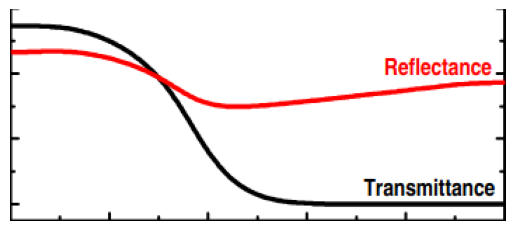

In [2]:
# Abrir la imagen desde el archivo especificado
# Esta imagen contiene las gráficas de reflectancia y transmitancia que necesitamos digitalizar
img = Image.open('/home/edgar/Imágenes/Capturas de pantalla/Captura desde 2026-03-04 12-36-57.png')

# Convertir la imagen a una matriz de NumPy
# Cada píxel estará representado como un array RGBA (Rojo, Verde, Azul, Alfa)
matriz = np.array(img)

# Imprimir las dimensiones de la matriz en formato (altura, ancho, canales de color)
# Esto nos ayuda a entender el tamaño de la imagen con la que trabajamos
print(matriz.shape)

# Mostrar la imagen en una gráfica de Matplotlib
plt.imshow(matriz)

# Ocultar los ejes para una visualización más limpia
plt.axis('off') 

# Mostrar la gráfica
plt.show()

### ***Código para obtener un array con la posicion de lo que necesitemos***

In [3]:
# EXTRACCIÓN DE DATOS DE LA IMAGEN
# El objetivo es identificar los píxeles que forman las curvas roja (reflectancia) 
# y negra (transmitancia) en la imagen, y convertirlos en coordenadas numéricas.

# Crear dos arrays para almacenar los puntos de la gráfica roja (reflectancia) y negra (transmitancia)
# Dimensiones: (354*151 = 53454) puntos posibles con 2 coordenadas cada uno (x, y)
grafica_roja = np.zeros((354*151, 2))
grafica_negra = np.zeros((354*151, 2))

# Definir factores de conversión de píxeles a unidades físicas
# 0.5 es el rango en el eje X (desde 1 a 1.5 en energía eV)
# 354 es el número de píxeles horizontales correspondientes a ese rango
division_E = 0.5/354

# 0.65 es el rango en el eje Y (reflectancia/transmitancia de 0 a 0.65)
# 151 es el número de píxeles verticales correspondientes a ese rango
division_alt = 0.65/151

# Inicializar variables para rastrear la altura y anchura de los píxeles
altura = 151  # Comienza desde la altura máxima
ancho = 0     # Comienza desde la anchura mínima

# Contadores para rastrear cuántos puntos se han identificado en cada curva
contador_rojo = 0
contador_negro = 0

# ========== PRIMER BUCLE: Detectar línea roja básica ==========
# Iteramos sobre cada fila de la matriz de imagen
for i in matriz:
    altura -= 1  # Decrementar la altura (procedemos de arriba a abajo)
    ancho = 0    # Reiniciar el contador de ancho para cada fila
    
    # Procesar solo cada 4ª fila para aumentar eficiencia (submuestreo vertical)
    if (altura+1)%4 == 0:
        # Iteramos sobre cada píxel en la fila i
        for j in i:
            # Detectar píxeles que son rojos: no completamente blancos ni negros
            if j[0] != 255 and j[0] != 0:
                # Evitar duplicados horizontales (mismo y) y repeticiones
                if grafica_roja[contador_rojo-1][1] != (altura+1) * division_alt:
                    # Evitar duplicados también en x, con límites razonables
                    if grafica_roja[contador_rojo-1][0] != (ancho) * division_E and ancho > 10 and ancho < 300:
                        # Guardar las coordenadas convertidas de píxeles a unidades físicas
                        grafica_roja[contador_rojo][0] = (ancho) * division_E 
                        grafica_roja[contador_rojo][1] = (altura+1) * division_alt
                        contador_rojo += 1
            
            # Detectar píxeles que son negros: alto valor en rojo, bajo en verde y azul
            elif j[0]>100 and j[1]<50 and j[2]<50:
                    # Similar a lo anterior, evitar duplicados
                    if grafica_negra[contador_negro-1][1] != (altura+1) * division_alt:
                        if grafica_negra[contador_negro-1][0] != (ancho) * division_E and ancho > 10 and ancho < 300:
                            grafica_negra[contador_negro][0] = (ancho) * division_E
                            grafica_negra[contador_negro][1] = (altura+1) * division_alt
                            contador_negro += 1
            
            ancho += 1

# Reinicializar variables para el siguiente bucle
altura = 151
ancho = 0

# ========== SEGUNDO BUCLE: Detectar línea negra adicional ==========
# Segundo barrido para capturar más píxeles negros que pudieron haberse perdido
for i in matriz:
    altura -= 1
    ancho = 0
    
    # Procesar cada 2ª fila (menos submuestreo que el anterior)
    if (altura+1)%2 == 0:
        for j in i:
            # Procesar solo cada 5º píxel horizontalmente
            if ancho%5 == 0:
                # Detectar píxeles negros oscuros
                if j[0]>80 and j[1]<30 and j[2]<30:
                    # Dos regiones específicas donde se espera encontrar la línea negra
                    if ancho > 150:
                        # Evitar duplicados verticales
                        if grafica_negra[contador_negro-1][1] != (altura+1) * division_alt:
                            grafica_negra[contador_negro][0] = (ancho) * division_E
                            grafica_negra[contador_negro][1] = (altura+1) * division_alt
                            contador_negro += 1
                    # Región inicial izquierda
                    elif ancho <50 and ancho>10 and (altura +1) < 122:
                        grafica_negra[contador_negro][0] = (ancho) * division_E
                        grafica_negra[contador_negro][1] = (altura+1) * division_alt
                        contador_negro += 1
            ancho+=1

# ========== TERCER BUCLE: Detectar línea roja adicional (región central) ==========
altura = 151
ancho = 0

for i in matriz:
    altura -= 1
    ancho = 0
    
    # Procesar cada 6ª fila
    if (altura+1)%6 == 0:
        for j in i:
            if ancho%5 == 0:
                # Detectar píxeles de color (no blancos ni negros)
                if j[0]!=255 and j[1]!=255 and j[2]!=255:
                    # Enfocarse en la región central derecha
                    if ancho > 200 and ancho < 300:
                        grafica_roja[contador_rojo][0] = (ancho) * division_E
                        grafica_roja[contador_rojo][1] = (altura+1) * division_alt
                        contador_rojo += 1
            ancho+=1

# ========== CUARTO BUCLE: Detectar línea roja adicional (región izquierda) ==========
altura = 151
ancho = 0

for i in matriz:
    altura -= 1
    ancho = 0
    
    # Procesar cada 6ª fila
    if (altura+1)%6 == 0:
        for j in i:
            # Procesar cada 4º píxel, dentro de límites específicos
            if ancho%4 == 0 and ancho<30 and altura>122 and ancho>10:
                # Detectar píxeles coloreados
                if j[0]!=255 and j[1]!=255 and j[2]!=255:
                    grafica_roja[contador_rojo][0] = (ancho) * division_E
                    grafica_roja[contador_rojo][1] = (altura+1) * division_alt
                    contador_rojo += 1
            ancho+=1

### ***Vision de lo extraido***

(1.0, 1.5)

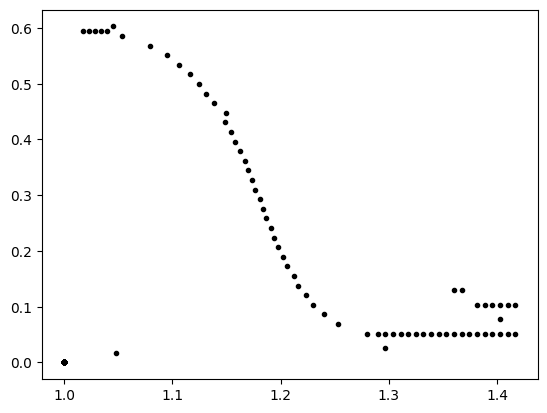

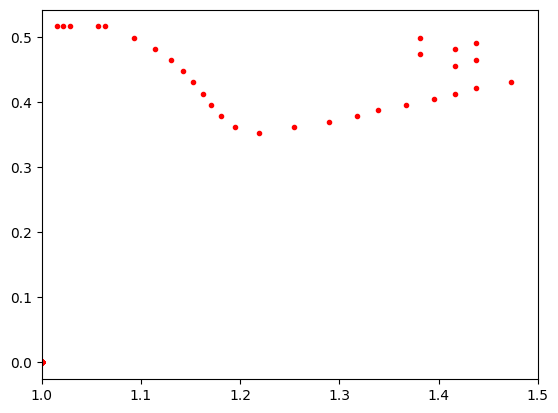

In [4]:
# VISUALIZACIÓN DE LOS DATOS EXTRAÍDOS
# Creamos gráficas para verificar si los datos extraídos son correctos

# Primera gráfica: Visualizar todos los puntos rojos extraídos (reflectancia)
plt.figure()
plt.plot(grafica_roja[:, 0]+1, grafica_roja[:, 1], 'k.')

# Segunda gráfica: Visualizar todos los puntos negros extraídos (transmitancia)
plt.figure()
plt.plot(grafica_negra[:, 0]+1, grafica_negra[:, 1], 'r.')
# Limitar el eje X para ver mejor los datos en la región de interés
plt.xlim(1, 1.5)

### ***Arreglo de los puntos***


En este paso eliminamos y además ajustamos la altura de los puntos para que concida con la gráfica, no hacemos la trasmitancia justo = ya que sino nos daría problemas el logaritmo

(-0.01, 0.6)

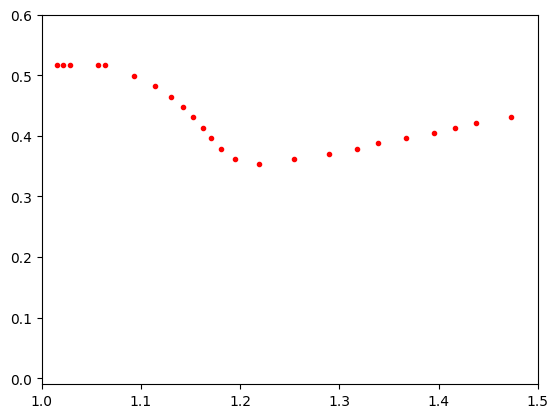

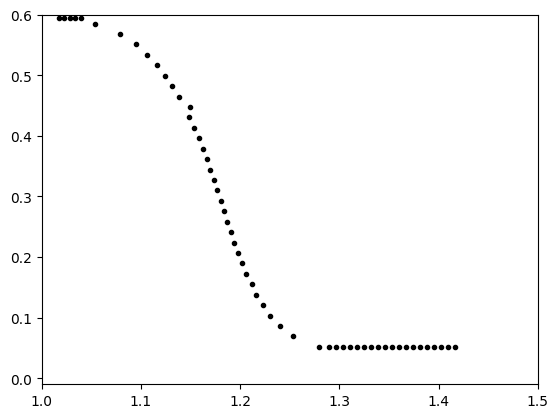

In [5]:
# AJUSTE Y LIMPIEZA DE LOS DATOS EXTRAÍDOS
# Modificamos las coordenadas X sumando 1 (ajuste de calibración de la imagen)
grafica_negra[:, 0] = grafica_negra[:,0]+1
grafica_roja[:, 0] = grafica_roja[:,0]+1

# ========== LIMPIEZA DE PUNTOS NEGROS ==========
# Identificar y eliminar puntos que no corresponden a la curva real
indices = []  # Lista para almacenar índices de puntos a eliminar

for i, array in enumerate(grafica_negra):
    # Identificar outliers y puntos fuera del rango esperado:
    # - Puntos con x entre 1.3-1.45 que tienen y > 0.43
    # - Puntos con y exactamente igual a 0 (sin datos)
    # - Puntos al principio (x < 1.04) que no están en el máximo
    if (array[0]>1.3 and array[0]<1.45 and array[1]>0.43) or array[1]==0 or (array[0]<1.04 and array[1]< max(grafica_negra[:, 1])):
        indices.append(i)

# Eliminar los índices identificados del array de gráfica negra
grafica_negra = np.delete(grafica_negra, indices, axis=0)

# ========== LIMPIEZA DE PUNTOS ROJOS ==========
# Identificar y eliminar puntos que no corresponden a la curva real
indices = []

for i, array in enumerate(grafica_roja):
    # Identificar outliers:
    # - Puntos con y entre 0.06-máx y x > 1.3 (región superior derecha)
    # - Puntos con y exactamente 0 (sin datos)
    # - Puntos con y < 0.04 (muy abajo, ruido)
    # - Puntos exactamente en el máximo y
    if (array[1]>0.06 and array[0]>1.3) or array[1]==0 or array[1]<0.04 or array[1] == max(grafica_roja[:, 1]):
        indices.append(i)

# Eliminar los índices identificados del array de gráfica roja
grafica_roja = np.delete(grafica_roja, indices, axis=0)

# VISUALIZAR LOS DATOS LIMPIOS
# Gráfica de puntos negros limpios (reflectancia)
plt.figure()
plt.plot(grafica_negra[:, 0], grafica_negra[:, 1], 'r.')
plt.xlim(1, 1.5)
plt.ylim(-0.01, 0.6)

# Gráfica de puntos rojos limpios (transmitancia)
plt.figure()
plt.plot(grafica_roja[:, 0], grafica_roja[:, 1], 'k.')
plt.xlim(1, 1.5)
plt.ylim(-0.01, 0.6)

In [6]:
# ORDENAMIENTO DE LOS PUNTOS POR COORDENADA X
# Para la interpolación correcta, los puntos deben estar ordenados por energía (eje X)

# Obtener los índices que ordenarían los arrays por su primera columna (energía)
indices_ordenados_negra = np.argsort(grafica_negra[:, 0])
indices_ordenados_roja = np.argsort(grafica_roja[:, 0])

# Reorganizar los arrays según los índices ordenados
grafica_negra_ordenada = grafica_negra[indices_ordenados_negra]
grafica_roja_ordenada = grafica_roja[indices_ordenados_roja]

# Eliminar un punto específico (índice 14) de la gráfica roja que es un outlier
grafica_roja_ordenada = np.delete(grafica_roja_ordenada, [14], axis=0)

(-0.01, 1.0)

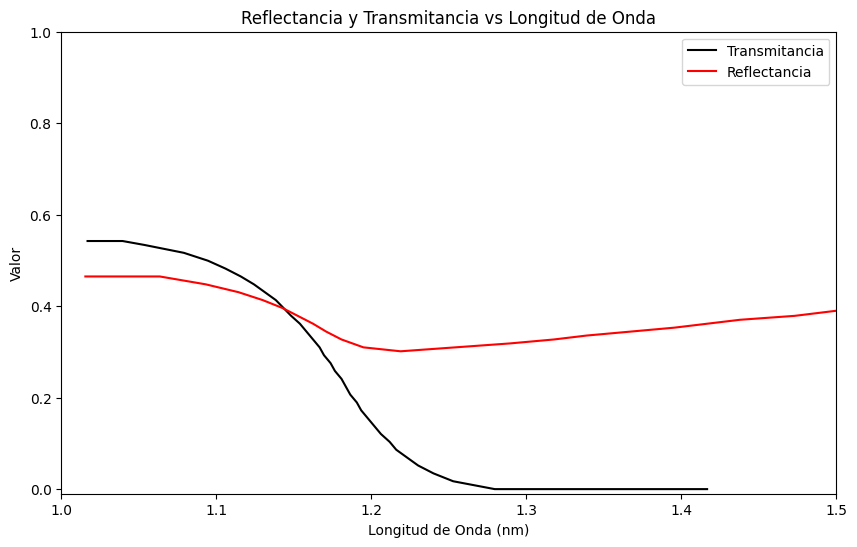

In [7]:
# AJUSTE DE VALORES Y CORRECIÓN DE CALIBRACIÓN
# Restar un offset a los valores de y (esto calibra el cero del eje)
grafica_negra_ordenada[:,1] = grafica_negra_ordenada[:,1] - 0.0516
grafica_roja_ordenada[:,1] = grafica_roja_ordenada[:,1] - 0.0516

# Añadir un punto de cierre a la gráfica negra en el extremo derecho
# Este punto (1.5, 0.39) marca el final de la curva de reflectancia
grafica_negra_ordenada = np.concatenate((grafica_negra_ordenada, np.array([[1.5, 0.39]])), axis=0)

# VISUALIZACIÓN DE LOS DATOS AJUSTADOS
plt.figure(figsize=(10, 6))

# Graficar la transmitancia (roja en la imagen, pero aquí en negro para consistencia)
plt.plot(grafica_roja_ordenada[:, 0], grafica_roja_ordenada[:, 1], 'k', label='Transmitancia')

# Graficar la reflectancia (negra en la imagen, pero aquí en rojo para consistencia visual)
plt.plot(grafica_negra_ordenada[:,  0], grafica_negra_ordenada[:, 1], 'r-', label='Reflectancia')

# Etiquetar los ejes
plt.xlabel('Longitud de Onda (nm)')
plt.ylabel('Valor')

# Título de la gráfica
plt.title('Reflectancia y Transmitancia vs Longitud de Onda')

# Mostrar leyenda
plt.legend()

# Establecer los límites de los ejes
plt.xlim(1, 1.5)
plt.ylim(-0.01, 1)

## ***Interpolación***

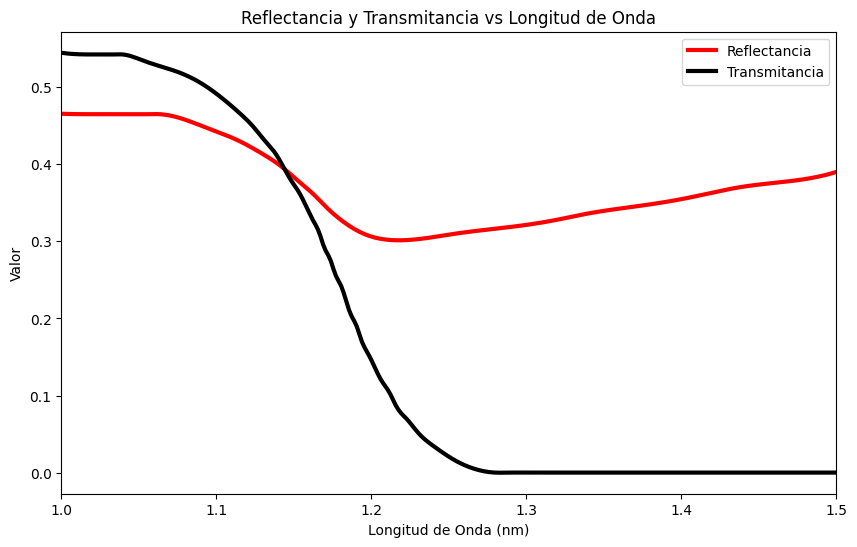

In [8]:
# INTERPOLACIÓN CÚBICA DE LOS DATOS
# Usar splines cúbicas para obtener funciones suaves a partir de los puntos discretos

# Crear una función continua de reflectancia usando interpolación cúbica
# Los puntos se interpolan usando splines cúbicas para suavidad
Reflectancia = CubicSpline(grafica_negra_ordenada[:, 0], grafica_negra_ordenada[:, 1])

# Crear una función continua de transmitancia usando interpolación cúbica
Transmitancia = CubicSpline(grafica_roja_ordenada[:, 0], grafica_roja_ordenada[:, 1])

# Crear una malla de puntos uniformemente espaciados en el intervalo [1, 1.5] eV
# Esto evaluará las funciones interpoladas en 300 puntos
mallado = np.linspace(1, 1.5, 300)

# VISUALIZACIÓN DE LAS CURVAS INTERPOLADAS
plt.figure(figsize=(10, 6))

# Graficar la reflectancia interpolada
plt.plot(mallado, Reflectancia(mallado), '-r', linewidth=3, label='Reflectancia')

# Graficar la transmitancia interpolada
plt.plot(mallado, Transmitancia(mallado), '-k', linewidth=3, label='Transmitancia')

# Establecer los límites del eje X
plt.xlim(1, 1.5)

# Etiquetar los ejes
plt.xlabel('Longitud de Onda (nm)')
plt.ylabel('Valor')

# Título de la gráfica
plt.title('Reflectancia y Transmitancia vs Longitud de Onda')

# Mostrar leyenda
plt.legend()

## ***Definición del coeficiente de absorción $\\alpha$***

In [9]:
# DEFINICION DE LA FUNCION DEL COEFICIENTE DE ABSORCION
# Esta funcion calcula el coeficiente de absorcion ($\alpha$) a partir de:
# - d: espesor del material
# - R: reflectancia
# - T: transmitancia
#
# La formula se basa en la relacion entre absorcion, reflexion y transmision
# en materiales opticos. El coeficiente $\alpha$ es crucial para determinar Eg.

def alpha(d, R, T):
    # Formula: $\alpha$ = (1/d) * ln(((1-R)^2/(2T)) + sqrt(((1-R)^4/(4T^2)) + R^2))
    # Esta expresion asegura que el termino dentro del logaritmo sea siempre positivo
    return (1 / d) * np.log(((1 - R) ** 2 / (2 * T)) + np.sqrt(((1 - R) ** 4 / ((T ** 2) * 4)) + R ** 2))

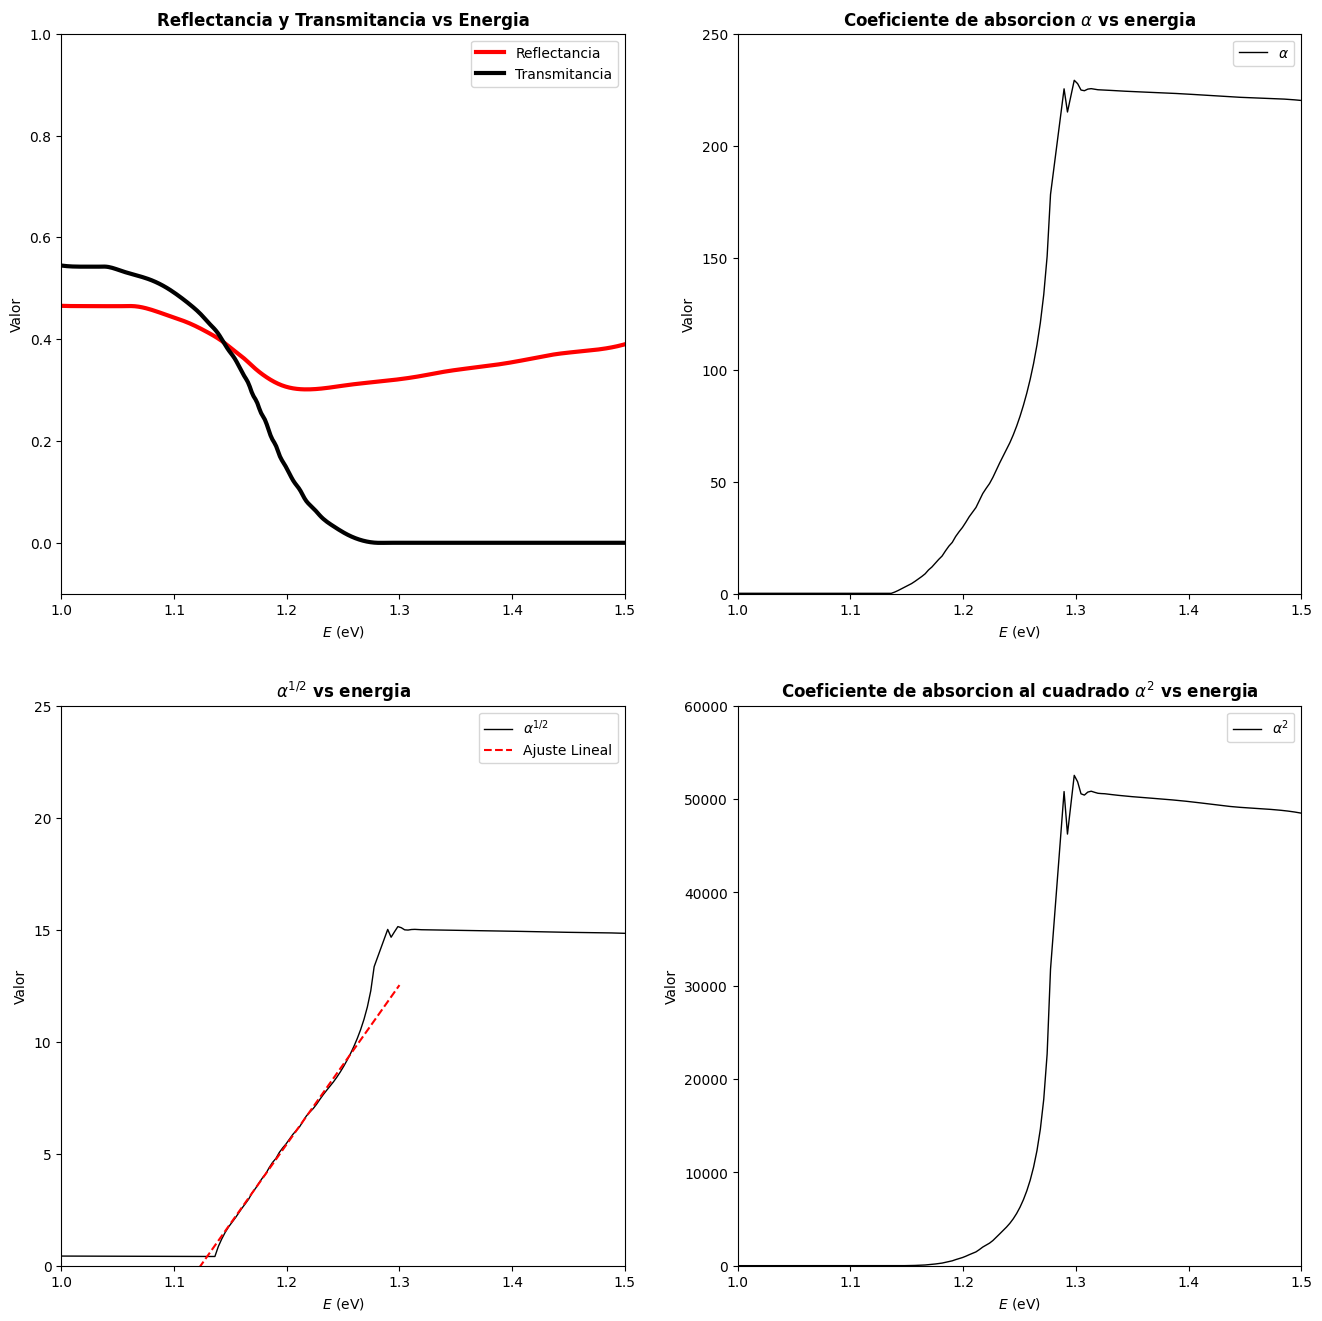

Pendiente (m): 71.02109336280033
Interseccion (b): -79.79921304974847
Eg (b/m): 1.1235987686377409


In [76]:
# CALCULO DEL COEFICIENTE DE ABSORCION Y DETERMINACION DE Eg
# Este es el paso final donde calculamos $\alpha$ para obtener la brecha de energia (Eg)

# ========== CONSTANTES FISICAS ==========
d = 0.04      # Espesor del material Silicon en cm
h = 6.626e-34 # Constante de Planck en J*s
c = 2.998e8   # Velocidad de la luz en m/s

# ========== CALCULO DE $\alpha$ EN LA MALLA DE ENERGIAS EXTENDIDA ==========
# Definir malla energetica extendida para evaluar $\alpha$ desde E=0 hasta 1.5 eV
x_malla_extendida_si = np.linspace(0, 1.5, 500)

# Calcular el coeficiente de absorcion para todas las energias en la malla extendida
alpha_values = alpha(d, Reflectancia(x_malla_extendida_si), Transmitancia(x_malla_extendida_si))

# Crear una mascara para valores validos (finitos y no negativas)
# El coeficiente de absorcion debe ser siempre positivo
mask = np.isfinite(alpha_values) & (alpha_values >= 0)

# Aplicar la mascara para obtener solo valores validos
alpha_values1 = alpha_values[mask]
mallado_1 = x_malla_extendida_si[mask]

# ========== CALCULOS PARA DETERMINAR Eg ==========
# Para semiconductores indirectos, se usa la relacion ($\alpha E$)^2 vs E
# Para semiconductores directos, se usa ($\alpha E$)^(1/2) vs E

# Calcular $\alpha^2$: cuadrado del coeficiente de absorcion
alpha_values_2 = alpha_values1**2

# Calcular $\alpha^{1/2}$: raiz cuadrada del coeficiente de absorcion
alpha_values_1_2 = np.sqrt(alpha_values1)

# ========== AJUSTE LINEAL PARA ENCONTRAR Eg ==========
# Seleccionar la region donde hacer el ajuste lineal (banda de absorcion principal)
mask_regresion = (mallado_1 > 1.15) & (mallado_1 < 1.23) & (alpha_values_1_2 > 0)

# Extraer los valores en la region de ajuste
x_regresion = mallado_1[mask_regresion]
alpha_values_2_regresion = alpha_values_1_2[mask_regresion]

# Calcular los coeficientes de la recta: $\alpha^{1/2}$ = m*E + b
# m es la pendiente y b es la interseccion con el eje Y
m, b = np.polyfit(x_regresion, alpha_values_2_regresion, 1)

# ========== VISUALIZACION DE RESULTADOS EN 4 SUBGRAFICAS ==========
fig, ax = plt.subplots(2, 2, figsize=(16, 16))

# ----- Subgrafica (0,0): Reflectancia y Transmitancia =====
ax[0,0].plot(mallado, Reflectancia(mallado), 'r-', linewidth=3, label='Reflectancia')
ax[0,0].plot(mallado, Transmitancia(mallado), 'k-', linewidth=3, label='Transmitancia')
ax[0,0].set_xlabel(r'$E$ (eV)')
ax[0,0].set_ylabel('Valor')
ax[0,0].set_title('Reflectancia y Transmitancia vs Energia', fontweight='bold')
ax[0,0].legend()
ax[0,0].set_xlim(1, 1.5)
ax[0,0].set_ylim(-0.1, 1)

# ----- Subgrafica (0,1): Coeficiente de absorcion $\alpha$ =====
# Grafica del coeficiente de absorcion sin transformar
ax[0,1].plot(mallado_1, alpha_values1, 'k-', linewidth=1, label=r'$\alpha$')
ax[0,1].set_xlabel(r'$E$ (eV)')
ax[0,1].set_ylabel('Valor')
ax[0,1].set_title(r'Coeficiente de absorcion $\alpha$ vs energia', fontweight='bold')
ax[0,1].legend()
ax[0,1].set_ylim(0, 250)
ax[0,1].set_xlim(1, 1.5)

# ----- Subgrafica (1,0): Raiz cuadrada del coeficiente $\alpha^{1/2}$ =====
# Este grafico se usa para determinar Eg (caso de semiconductores indirectos)
ax[1,0].plot(mallado_1, alpha_values_1_2, 'k-', linewidth=1, label=r'$\alpha^{1/2}$')

# Graficar la linea de ajuste lineal en la region de interes
# Extender la linea mas alla de la region de ajuste para ver la interseccion
x_recta = np.array([1, 1.30])
y_recta = m * x_recta + b
ax[1,0].plot(x_recta, y_recta, 'r--', label='Ajuste Lineal')

ax[1,0].set_xlabel(r'$E$ (eV)')
ax[1,0].set_ylabel('Valor')
ax[1,0].set_title(r'$\alpha^{1/2}$ vs energia', fontweight='bold')
ax[1,0].legend()
ax[1,0].set_xlim(1, 1.5)
ax[1,0].set_ylim(0, 25)

# ----- Subgrafica (1,1): Cuadrado del coeficiente $\alpha^2$ =====
# Este grafico se usa para determinar Eg (caso de semiconductores directos)
ax[1,1].plot(mallado_1, alpha_values_2, 'k-', linewidth=1, label=r'$\alpha^2$')
ax[1,1].set_xlabel(r'$E$ (eV)')
ax[1,1].set_ylabel('Valor')
ax[1,1].set_title(r'Coeficiente de absorcion al cuadrado $\alpha^2$ vs energia', fontweight='bold')
ax[1,1].legend()
ax[1,1].set_xlim(1, 1.5)
ax[1,1].set_ylim(0, 6e4)

# Mostrar todas las subgraficas
plt.show()

# ========== RESULTADOS FINALES ==========
# Imprimir los parametros del ajuste y calcular Eg
print(f"Pendiente (m): {m}")
print(f"Interseccion (b): {b}")
# Eg se obtiene donde la recta intersecta el eje X (donde $\alpha^{1/2}$ = 0)
# Resolviendo: 0 = m*Eg + b -> Eg = -b/m
print(f"Eg (b/m): {-b/m}")

# ***Digitalización de las gráficas y obtención de $E_{gap}$ para el $c-GaAs$***

## ***Imagen que vamos a usar***

(101, 236, 4)


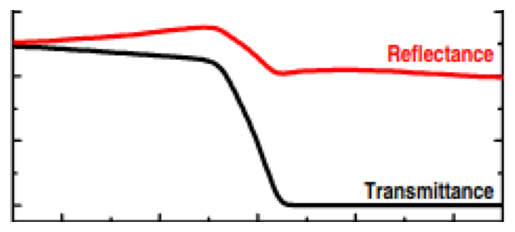

In [11]:
# Abrir la imagen desde el archivo especificado
# Esta imagen contiene las gráficas de reflectancia y transmitancia que necesitamos digitalizar
img_gaas = Image.open('/home/edgar/Imágenes/Capturas de pantalla/Captura desde 2026-03-05 17-59-10.png')

# Convertir la imagen a una matriz de NumPy
# Cada píxel estará representado como un array RGBA (Rojo, Verde, Azul, Alfa)
matriz_gaas = np.array(img_gaas)

# Imprimir las dimensiones de la matriz en formato (altura, ancho, canales de color)
# Esto nos ayuda a entender el tamaño de la imagen con la que trabajamos
print(matriz_gaas.shape)

# Mostrar la imagen en una gráfica de Matplotlib
plt.imshow(matriz_gaas)

# Ocultar los ejes para una visualización más limpia
plt.axis('off') 

# Mostrar la gráfica
plt.show()


## ***Extracción de puntos de la imagen (c-GaAs)***

> Reutilizamos la lógica de digitalización para obtener los puntos de reflectancia y transmitancia en coordenadas físicas.
El objetivo es construir dos nubes de puntos iniciales que después limpiaremos y suavizaremos.

In [12]:
# EXTRACCION DE DATOS DE LA IMAGEN DE c-GaAs
# Identificamos pixeles de las curvas y los convertimos a coordenadas (E, valor).

# Reservar memoria para los puntos de ambas curvas.
# Se usa un tamano maximo (ancho * alto) para no redimensionar durante el barrido.
grafica_roja = np.zeros((354 * 151, 2))
grafica_negra = np.zeros((354 * 151, 2))

# Factores de conversion pixel -> unidades de la grafica.
# Eje X: 0.6 eV distribuidos en 236 pixeles utiles.
division_E = 0.6 / 236

# Eje Y: 0.65 unidades distribuidas en 101 pixeles utiles.
division_alt = 0.65 / 101

# Variables de control de barrido.
altura = 101
ancho = 0

# Contadores de puntos detectados para cada curva.
contador_rojo = 0
contador_negro = 0

# Recorremos fila a fila toda la imagen de la grafica de GaAs.
for fila in matriz_gaas:
    altura -= 1
    ancho = 0

    # En esta version se usa cada fila (sin submuestreo vertical).
    if (altura + 1) % 1 == 0:
        for pixel in fila:
            # Curva roja: pixeles no blancos y no negros puros.
            if pixel[0] != 255 and pixel[0] != 0:
                # Submuestreo horizontal para reducir ruido y duplicados.
                if ancho % 6 == 0:
                    grafica_roja[contador_rojo, 0] = ancho * division_E
                    grafica_roja[contador_rojo, 1] = (altura + 1) * division_alt
                    contador_rojo += 1

            # Curva negra: umbral de color compatible con trazo oscuro rojizo.
            elif pixel[0] > 100 and pixel[1] < 50 and pixel[2] < 50:
                # Submuestreo horizontal ligeramente distinto para esta curva.
                if ancho % 4 == 0:
                    grafica_negra[contador_negro, 0] = ancho * division_E
                    grafica_negra[contador_negro, 1] = (altura + 1) * division_alt
                    contador_negro += 1

            ancho += 1

# Nota: en esta fase aun quedan ceros y puntos espurios; se depuran en las celdas siguientes.

(1.0, 1.5)

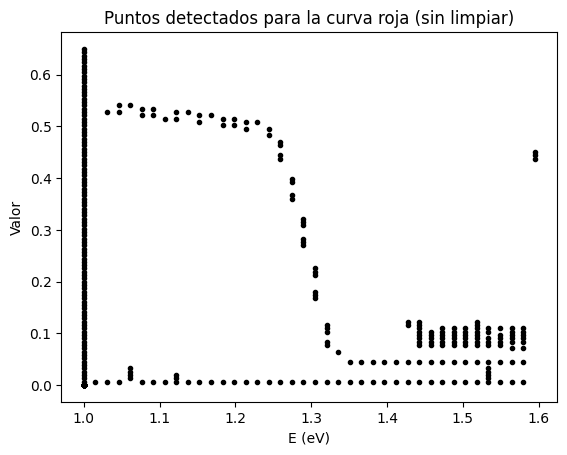

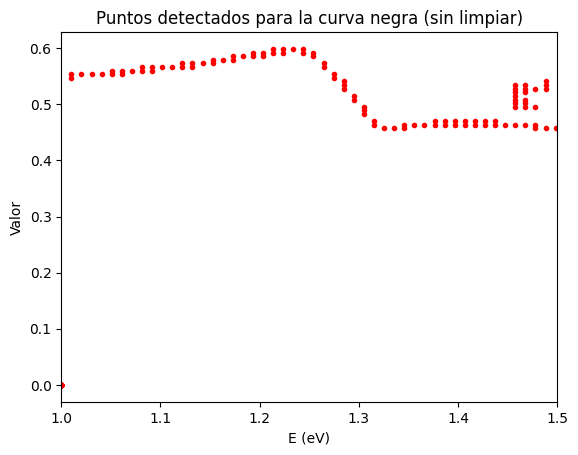

In [13]:
# VISUALIZACION PRELIMINAR DE LOS PUNTOS EXTRAIDOS
# Esta vista permite comprobar si la deteccion de pixeles capta la forma global de ambas curvas.

plt.figure()
plt.plot(grafica_roja[:, 0] + 1, grafica_roja[:, 1], 'k.')
plt.title('Puntos detectados para la curva roja (sin limpiar)')
plt.xlabel('E (eV)')
plt.ylabel('Valor')

plt.figure()
plt.plot(grafica_negra[:, 0] + 1, grafica_negra[:, 1], 'r.')
plt.title('Puntos detectados para la curva negra (sin limpiar)')
plt.xlabel('E (eV)')
plt.ylabel('Valor')
plt.xlim(1, 1.5)

### ***Filtrado inicial de ruido y separación de curvas***

> En esta etapa aplicamos máscaras para eliminar zonas claramente no físicas y separar mejor las dos curvas.
Después refinaremos cada curva por coordenada `x` para quedarnos con un único punto representativo por columna.

(1.0, 1.5)

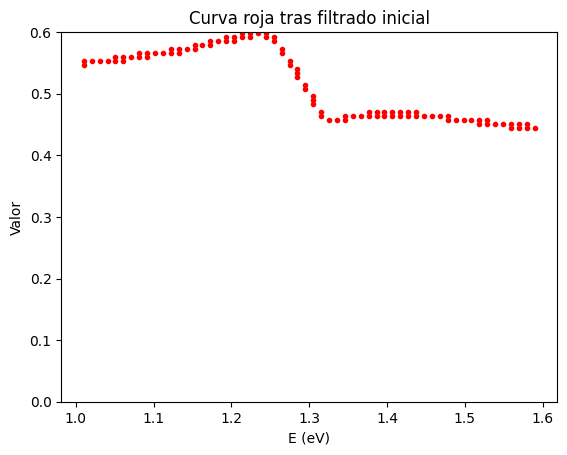

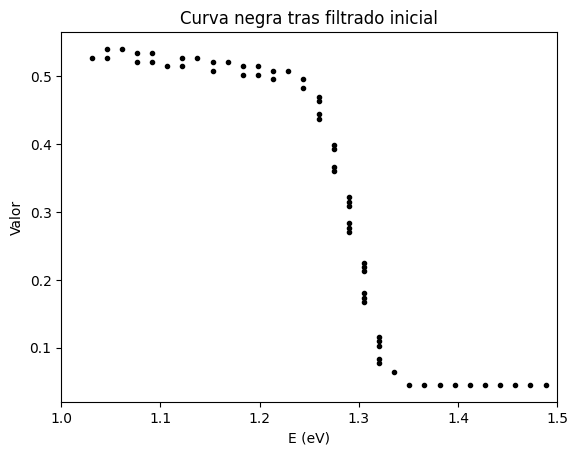

In [14]:
# FILTRADO INICIAL DE PUNTOS PARA c-GaAs
# Se aplican mascaras heuristicas para eliminar ruido y separar mejor cada curva.

# 1) Filtrar puntos de la nube original (negra) para construir la curva roja final.
#    Se eliminan puntos altos en x grandes y puntos nulos (x == 0).
mask_roja = ((grafica_negra[:, 1] > 0.47) & (grafica_negra[:, 0] > 0.4)) | (grafica_negra[:, 0] == 0)
grafica_roja_2 = grafica_negra[~mask_roja]

# 2) Filtrar la nube original (roja) para construir la curva negra final.
#    Nos quedamos con puntos por encima de un umbral minimo de y y x.
mask_negra = (grafica_roja[:, 1] > 0.034) & (grafica_roja[:, 0] > 0.01)
grafica_negra_2 = grafica_roja[mask_negra]

# 3) Filtrado adicional sobre la curva negra para retirar una banda alta no deseada.
mask_2_negra = (grafica_negra_2[:, 1] > 0.048) & (grafica_negra_2[:, 0] > 0.4)
grafica_negra_2 = grafica_negra_2[~mask_2_negra]

# Visualizacion tras el filtrado inicial.
plt.figure()
plt.plot(grafica_roja_2[:, 0] + 1, grafica_roja_2[:, 1], 'r.')
plt.title('Curva roja tras filtrado inicial')
plt.xlabel('E (eV)')
plt.ylabel('Valor')
plt.ylim(0, 0.6)

plt.figure()
plt.plot(grafica_negra_2[:, 0] + 1, grafica_negra_2[:, 1], 'k.')
plt.title('Curva negra tras filtrado inicial')
plt.xlabel('E (eV)')
plt.ylabel('Valor')
plt.xlim(1, 1.5)

### ***Depuración por coordenada x y ajuste fino de puntos***

> Aquí reducimos duplicados por columna `x`, aplicamos correcciones manuales y realizamos un suavizado discreto para mejorar la estabilidad de la interpolación cúbica.

Puntos roja_2: 95 -> 31
Puntos negra_2: 66 -> 27
Puntos eliminados en roja (0 < x < 0.23): 11
Puntos especificos eliminados de roja [3,5,7]: 3
Puntos eliminados en roja (x >= 0.32): 13


(1.0, 1.5)

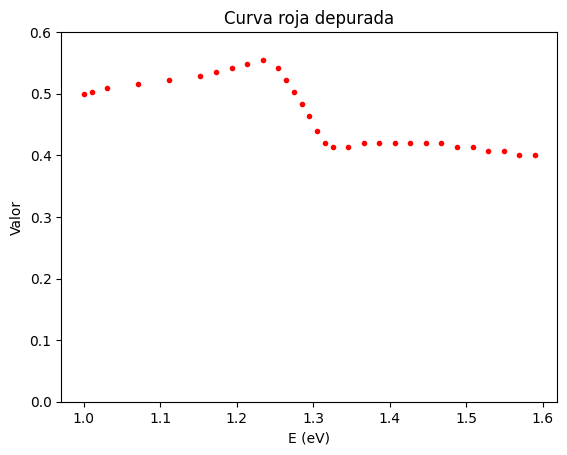

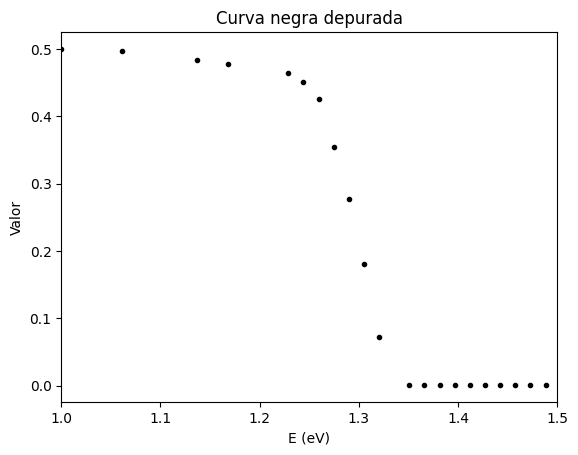

In [15]:
# DEPURACION FINA DE LAS CURVAS PARA c-GaAs
# Objetivo: dejar una sola altura representativa por cada x y suavizar ruido local.

def mantener_extremo_altura_por_x(datos, modo='min'):
    # Para cada valor repetido de x conserva solo un punto extremo en y.
    # modo='min' mantiene el punto mas bajo; modo='max' mantiene el mas alto.
    if datos.size == 0:
        return datos

    x = datos[:, 0]
    y = datos[:, 1]
    indices_a_conservar = []

    for x_valor in np.unique(x):
        indices_x = np.where(x == x_valor)[0]
        if modo == 'max':
            indice_extremo = indices_x[np.argmax(y[indices_x])]
        else:
            indice_extremo = indices_x[np.argmin(y[indices_x])]
        indices_a_conservar.append(indice_extremo)

    # Reordenar indices para conservar el orden de aparicion en el array original.
    indices_a_conservar = np.array(sorted(indices_a_conservar), dtype=int)
    return datos[indices_a_conservar]

# Guardar tamanos iniciales para diagnostico.
n_roja_inicial = len(grafica_roja_2)
n_negra_inicial = len(grafica_negra_2)

# Roja: para cada x, conservar la menor altura (perfil inferior).
grafica_roja_2 = mantener_extremo_altura_por_x(grafica_roja_2, modo='min')

# Negra: para cada x, conservar la mayor altura (perfil superior).
grafica_negra_2 = mantener_extremo_altura_por_x(grafica_negra_2, modo='max')

# Ordenar ambas curvas por x para operaciones posteriores.
grafica_roja_2 = grafica_roja_2[np.argsort(grafica_roja_2[:, 0])]
grafica_negra_2 = grafica_negra_2[np.argsort(grafica_negra_2[:, 0])]

# Eliminar algunos indices concretos de la curva negra tras inspeccion visual.
indices_a_eliminar = np.array([0, 1, 3, 4, 5, 6, 8, 10, 11, 12, 20], dtype=int)
indices_validos = indices_a_eliminar[indices_a_eliminar < len(grafica_negra_2)]
grafica_negra_2 = np.delete(grafica_negra_2, indices_validos, axis=0)

# Ajuste vertical global para alinear ambas curvas con el eje de referencia.
grafica_roja_2[:, 1] = grafica_roja_2[:, 1] - 0.044
grafica_negra_2[:, 1] = grafica_negra_2[:, 1] - 0.044

# Agregar punto ancla (x=0, y=0.5) en ambas curvas.
# Primero se elimina cualquier duplicado previo para evitar acumulacion al reejecutar.
punto_extra = np.array([[0.0, 0.5]])
grafica_roja_2 = grafica_roja_2[grafica_roja_2[:, 0] != 0.0]
grafica_negra_2 = grafica_negra_2[grafica_negra_2[:, 0] != 0.0]
grafica_roja_2 = np.vstack((grafica_roja_2, punto_extra))
grafica_negra_2 = np.vstack((grafica_negra_2, punto_extra))

# Reordenar de nuevo tras insertar el punto ancla.
grafica_roja_2 = grafica_roja_2[np.argsort(grafica_roja_2[:, 0])]
grafica_negra_2 = grafica_negra_2[np.argsort(grafica_negra_2[:, 0])]

# Suavizado 1 de la roja: en 0 < x < 0.23 quitar un punto de cada dos.
mask_rango_roja = (grafica_roja_2[:, 0] > 0.0) & (grafica_roja_2[:, 0] < 0.23)
indices_rango_roja = np.where(mask_rango_roja)[0]
indices_roja_a_quitar = indices_rango_roja[1::2]
grafica_roja_2 = np.delete(grafica_roja_2, indices_roja_a_quitar, axis=0)

# Eliminar algunos puntos concretos que aun actuan como outliers.
indices_especificos = np.array([3, 5, 7], dtype=int)
indices_validos_roja = indices_especificos[indices_especificos < len(grafica_roja_2)]
grafica_roja_2 = np.delete(grafica_roja_2, indices_validos_roja, axis=0)

# Suavizado 2 de la roja: para x >= 0.32 volver a quitar un punto de cada dos.
mask_rango_roja_32 = grafica_roja_2[:, 0] >= 0.32
indices_rango_roja_32 = np.where(mask_rango_roja_32)[0]
indices_roja_a_quitar_32 = indices_rango_roja_32[1::2]
grafica_roja_2 = np.delete(grafica_roja_2, indices_roja_a_quitar_32, axis=0)

# Ajuste manual antes de interpolar:
# mover el punto 10 ligeramente por encima del punto 9 (indices 9 y 8 en base 0).
grafica_roja_2 = np.delete(grafica_roja_2, 10, axis=0)

# Resumen de limpieza y suavizado.
print(f"Puntos roja_2: {n_roja_inicial} -> {len(grafica_roja_2)}")
print(f"Puntos negra_2: {n_negra_inicial} -> {len(grafica_negra_2)}")
print(f"Puntos eliminados en roja (0 < x < 0.23): {len(indices_roja_a_quitar)}")
print(f"Puntos especificos eliminados de roja [3,5,7]: {len(indices_validos_roja)}")
print(f"Puntos eliminados en roja (x >= 0.32): {len(indices_roja_a_quitar_32)}")

# Visualizacion final de las nubes de puntos depuradas.
plt.figure()
plt.plot(grafica_roja_2[:, 0] + 1, grafica_roja_2[:, 1], 'r.')
plt.title('Curva roja depurada')
plt.xlabel('E (eV)')
plt.ylabel('Valor')
plt.ylim(0, 0.6)

plt.figure()
plt.plot(grafica_negra_2[:, 0] + 1, grafica_negra_2[:, 1], 'k.')
plt.title('Curva negra depurada')
plt.xlabel('E (eV)')
plt.ylabel('Valor')
plt.xlim(1, 1.5)

### ***Interpolación de reflectancia y transmitancia (c-GaAs)***

> Tras depurar los puntos, construimos funciones continuas con `CubicSpline` para evaluar ambas curvas de forma estable en una malla fina de energía.

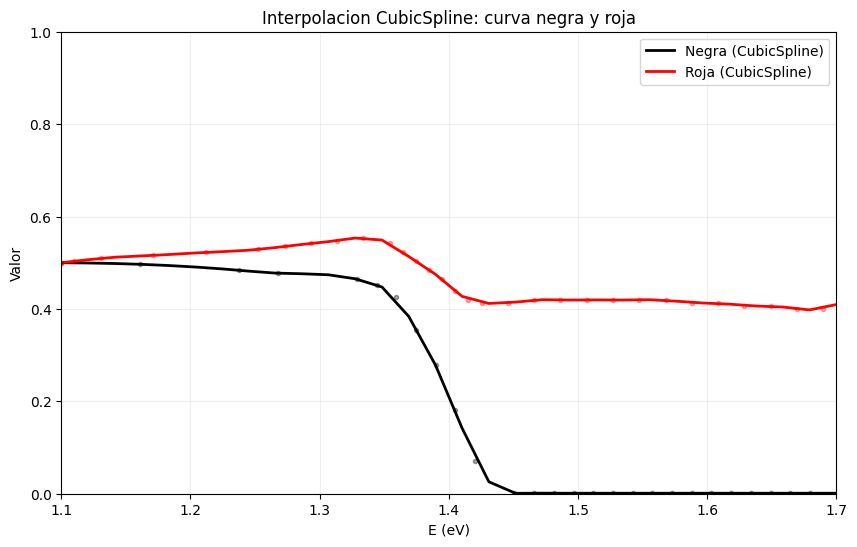

In [16]:
# INTERPOLACION CUBICA PARA c-GaAs
# Se generan funciones suaves de ambas curvas para poder calcular alpha(E).

# Crear copias para evitar modificar arrays base al reejecutar la celda.
negra_interp = grafica_negra_2.copy()
roja_interp = grafica_roja_2.copy()

# Aplicar offset horizontal para alinear el eje de energia.
negra_interp[:, 0] = negra_interp[:, 0] + 1.1
roja_interp[:, 0] = roja_interp[:, 0] + 1.1

# Ordenar por x antes de interpolar.
negra_interp = negra_interp[np.argsort(negra_interp[:, 0])]
roja_interp = roja_interp[np.argsort(roja_interp[:, 0])]

# CubicSpline requiere x estrictamente creciente; por eso quitamos x repetidas.
x_negra, idx_negra = np.unique(negra_interp[:, 0], return_index=True)
y_negra = negra_interp[idx_negra, 1]

x_roja, idx_roja = np.unique(roja_interp[:, 0], return_index=True)
y_roja = roja_interp[idx_roja, 1]

# Construir splines cubicas para ambas curvas.
spline_negra = CubicSpline(x_negra, y_negra)
spline_roja = CubicSpline(x_roja, y_roja)

# Definir malla fina de energia en el rango de interes.
x_malla = np.linspace(1.1, 1.7, 30)

# Visualizar curvas interpoladas junto a puntos de referencia.
plt.figure(figsize=(10, 6))
plt.plot(x_malla, spline_negra(x_malla), 'k-', linewidth=2, label='Negra (CubicSpline)')
plt.plot(x_malla, spline_roja(x_malla), 'r-', linewidth=2, label='Roja (CubicSpline)')

# Puntos discretos (atenuados) para comparar spline vs datos base.
plt.plot(negra_interp[:, 0], negra_interp[:, 1], 'k.', alpha=0.35)
plt.plot(roja_interp[:, 0], roja_interp[:, 1], 'r.', alpha=0.35)

plt.xlim(1.1, 1.7)
plt.ylim(0, 1)
plt.xlabel('E (eV)')
plt.ylabel('Valor')
plt.title('Interpolacion CubicSpline: curva negra y roja')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### ***Cálculo de \\(\\alpha\\) y estimación de \\(E_g\\) para c-GaAs***

> Con las curvas interpoladas calculamos el coeficiente de absorción y realizamos un ajuste lineal en la zona de borde de absorción para extraer el valor de `E_g`.

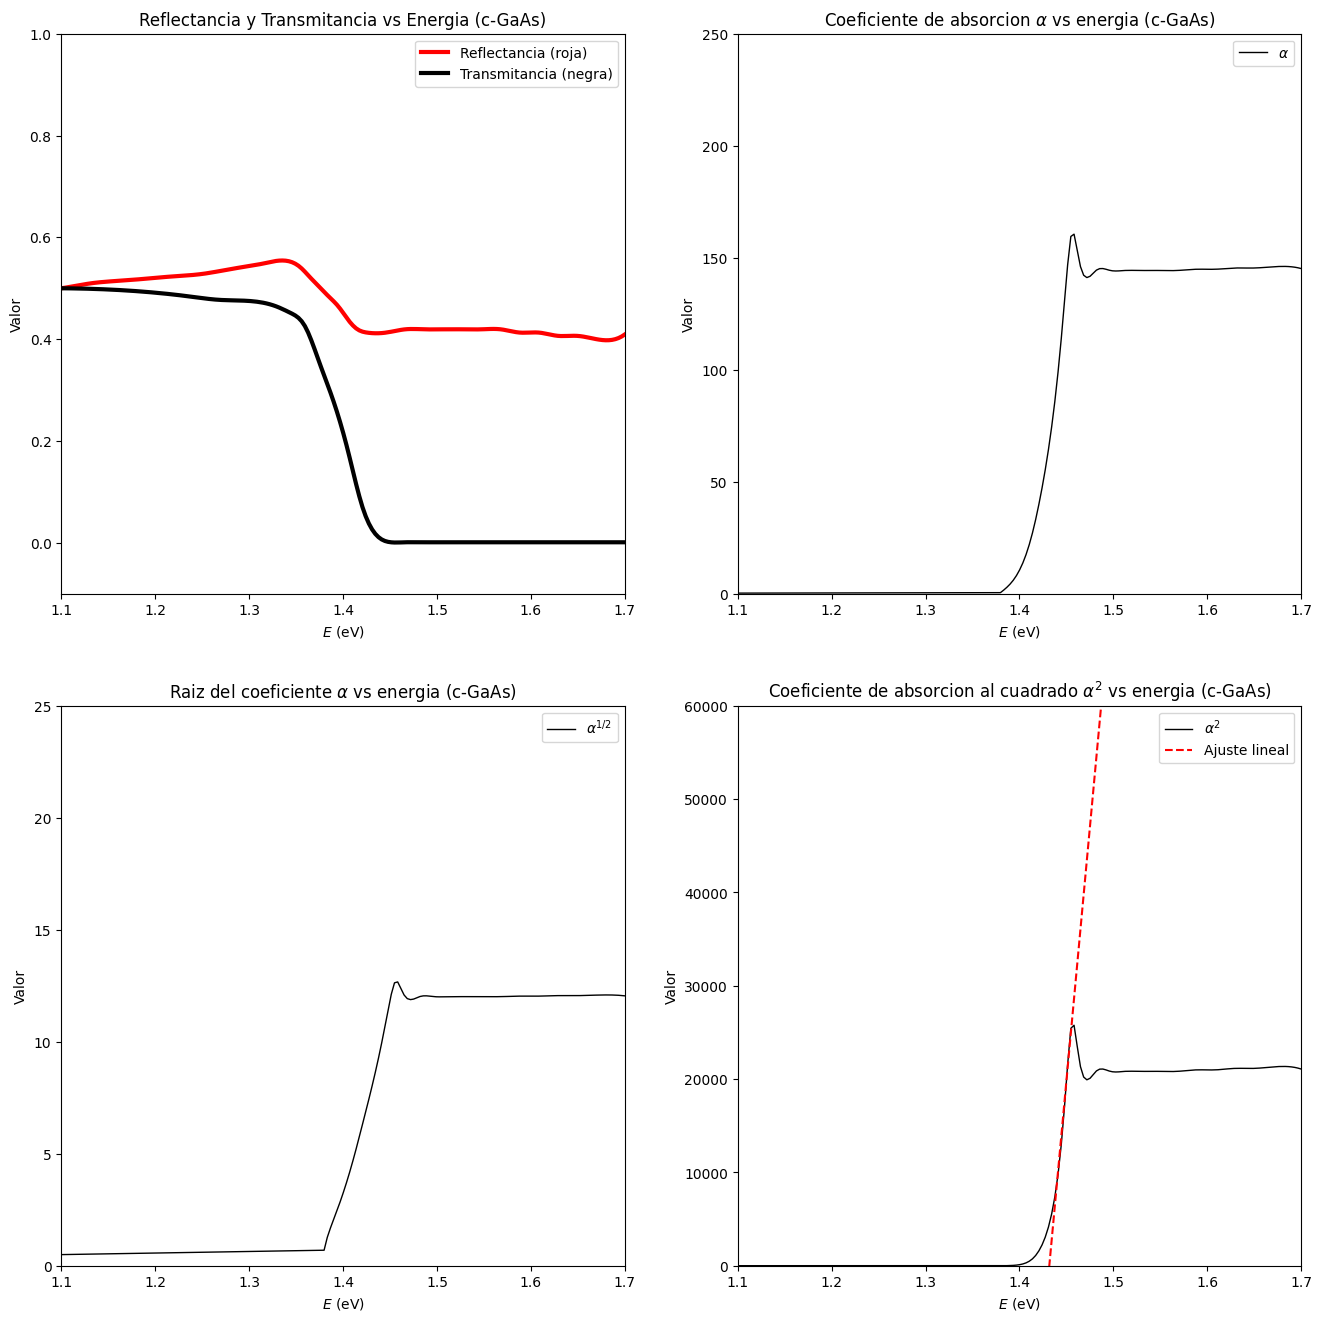

Puntos en malla_gaas: 372
Rango de malla_gaas: [0.000, 1.700]
Puntos perdidos por filtrado: 128

c-GaAs - Pendiente (m): 1087006.8604047936
c-GaAs - Interseccion (b): -1556338.502510425
c-GaAs - Eg (-b/m): 1.4317651150157926


In [68]:
# CALCULO DEL COEFICIENTE DE ABSORCION Y DE Eg PARA c-GaAs
# Procedimiento analogo al caso c-Si, adaptado al rango energetico de GaAs.

# Para este bloque: curva roja -> reflectancia, curva negra -> transmitancia.

d_gaas = 0.04  # Espesor del material en cm.
h = 6.626e-34  # Constante de Planck en J*s (se mantiene por coherencia fisica).
c = 2.998e8    # Velocidad de la luz en m/s (se mantiene por coherencia fisica).

# Definir malla energetica extendida para evaluar $\alpha$ desde E=0 hasta 1.7 eV.
x_malla_extendida = np.linspace(0, 1.7, 500)

# Evaluar $\alpha(E)$ usando las curvas interpoladas.
alpha_values_gaas = alpha(d_gaas, spline_roja(x_malla_extendida), spline_negra(x_malla_extendida))

# Conservar solo valores fisicamente validos: finitos y no negativos.
mask_gaas = np.isfinite(alpha_values_gaas) & (alpha_values_gaas >= 0)
alpha_values1_gaas = alpha_values_gaas[mask_gaas]
malla_gaas = x_malla_extendida[mask_gaas]

# Transformaciones utiles para analisis de transiciones opticas.
alpha_values_2_gaas = alpha_values1_gaas ** 2
alpha_values_1_2_gaas = alpha_values1_gaas**0.5

# Seleccionar ventana de ajuste lineal alrededor del borde de absorcion.
mask_regresion_gaas = (malla_gaas > 1.436) & (malla_gaas < 1.456) & (alpha_values_2_gaas > 0)
x_regresion_gaas = malla_gaas[mask_regresion_gaas]
alpha_values_2_regresion_gaas = alpha_values_2_gaas[mask_regresion_gaas]

# Ajuste lineal de la forma $\alpha^2$ = m*E + b en la region seleccionada.
m_gaas, b_gaas = np.polyfit(x_regresion_gaas, alpha_values_2_regresion_gaas, 1)

# Visualizacion de resultados en cuatro paneles complementarios.
fig, ax = plt.subplots(2, 2, figsize=(16, 16))

# (0,0) Curvas R y T.
ax[0, 0].plot(x_malla_extendida, spline_roja(x_malla_extendida), 'r-', linewidth=3, label='Reflectancia (roja)')
ax[0, 0].plot(x_malla_extendida, spline_negra(x_malla_extendida), 'k-', linewidth=3, label='Transmitancia (negra)')
ax[0, 0].set_xlabel(r'$E$ (eV)')
ax[0, 0].set_ylabel('Valor')
ax[0, 0].set_title('Reflectancia y Transmitancia vs Energia (c-GaAs)')
ax[0, 0].legend()
ax[0, 0].set_xlim(1.1, 1.7)
ax[0, 0].set_ylim(-0.1, 1)

# (0,1) Coeficiente de absorcion $\alpha$.
ax[0, 1].plot(malla_gaas, alpha_values1_gaas, 'k-', linewidth=1, label=r'$\alpha$')
ax[0, 1].set_xlabel(r'$E$ (eV)')
ax[0, 1].set_ylabel('Valor')
ax[0, 1].set_title(r'Coeficiente de absorcion $\alpha$ vs energia (c-GaAs)')
ax[0, 1].legend()
ax[0, 1].set_ylim(0, 250)
ax[0, 1].set_xlim(1.1, 1.7)

# (1,0) Raiz de $\alpha$, util para contraste metodologico.
ax[1, 0].plot(malla_gaas, alpha_values_1_2_gaas, 'k-', linewidth=1, label=r'$\alpha^{1/2}$')
ax[1, 0].set_xlabel(r'$E$ (eV)')
ax[1, 0].set_ylabel('Valor')
ax[1, 0].set_title(r'Raiz del coeficiente $\alpha$ vs energia (c-GaAs)')
ax[1, 0].legend()
ax[1, 0].set_xlim(1.1, 1.7)
ax[1, 0].set_ylim(0, 25)

# (1,1) $\alpha^2$ y recta de ajuste para extraer Eg.
ax[1, 1].plot(malla_gaas, alpha_values_2_gaas, 'k-', linewidth=1, label=r'$\alpha^2$')
x_recta = np.array([1.3, 1.5])
y_recta = m_gaas * x_recta + b_gaas
ax[1, 1].plot(x_recta, y_recta, 'r--', label='Ajuste lineal')
ax[1, 1].set_xlabel(r'$E$ (eV)')
ax[1, 1].set_ylabel('Valor')
ax[1, 1].set_title(r'Coeficiente de absorcion al cuadrado $\alpha^2$ vs energia (c-GaAs)')
ax[1, 1].legend()
ax[1, 1].set_xlim(1.1, 1.7)
ax[1, 1].set_ylim(0, 6e4)

plt.show()

# Diagnostico de consistencia de la malla y el filtrado.
print(f"Puntos en malla_gaas: {len(malla_gaas)}")
print(f"Rango de malla_gaas: [{malla_gaas.min():.3f}, {malla_gaas.max():.3f}]")
print(f"Puntos perdidos por filtrado: {len(x_malla_extendida) - len(malla_gaas)}")

# Resultado final: interseccion con el eje X de la recta ajustada.
# Si $\alpha^2$ = m*E + b, entonces Eg = -b/m.
print(f"\nc-GaAs - Pendiente (m): {m_gaas}")
print(f"c-GaAs - Interseccion (b): {b_gaas}")
print(f"c-GaAs - Eg (-b/m): {-b_gaas / m_gaas}")

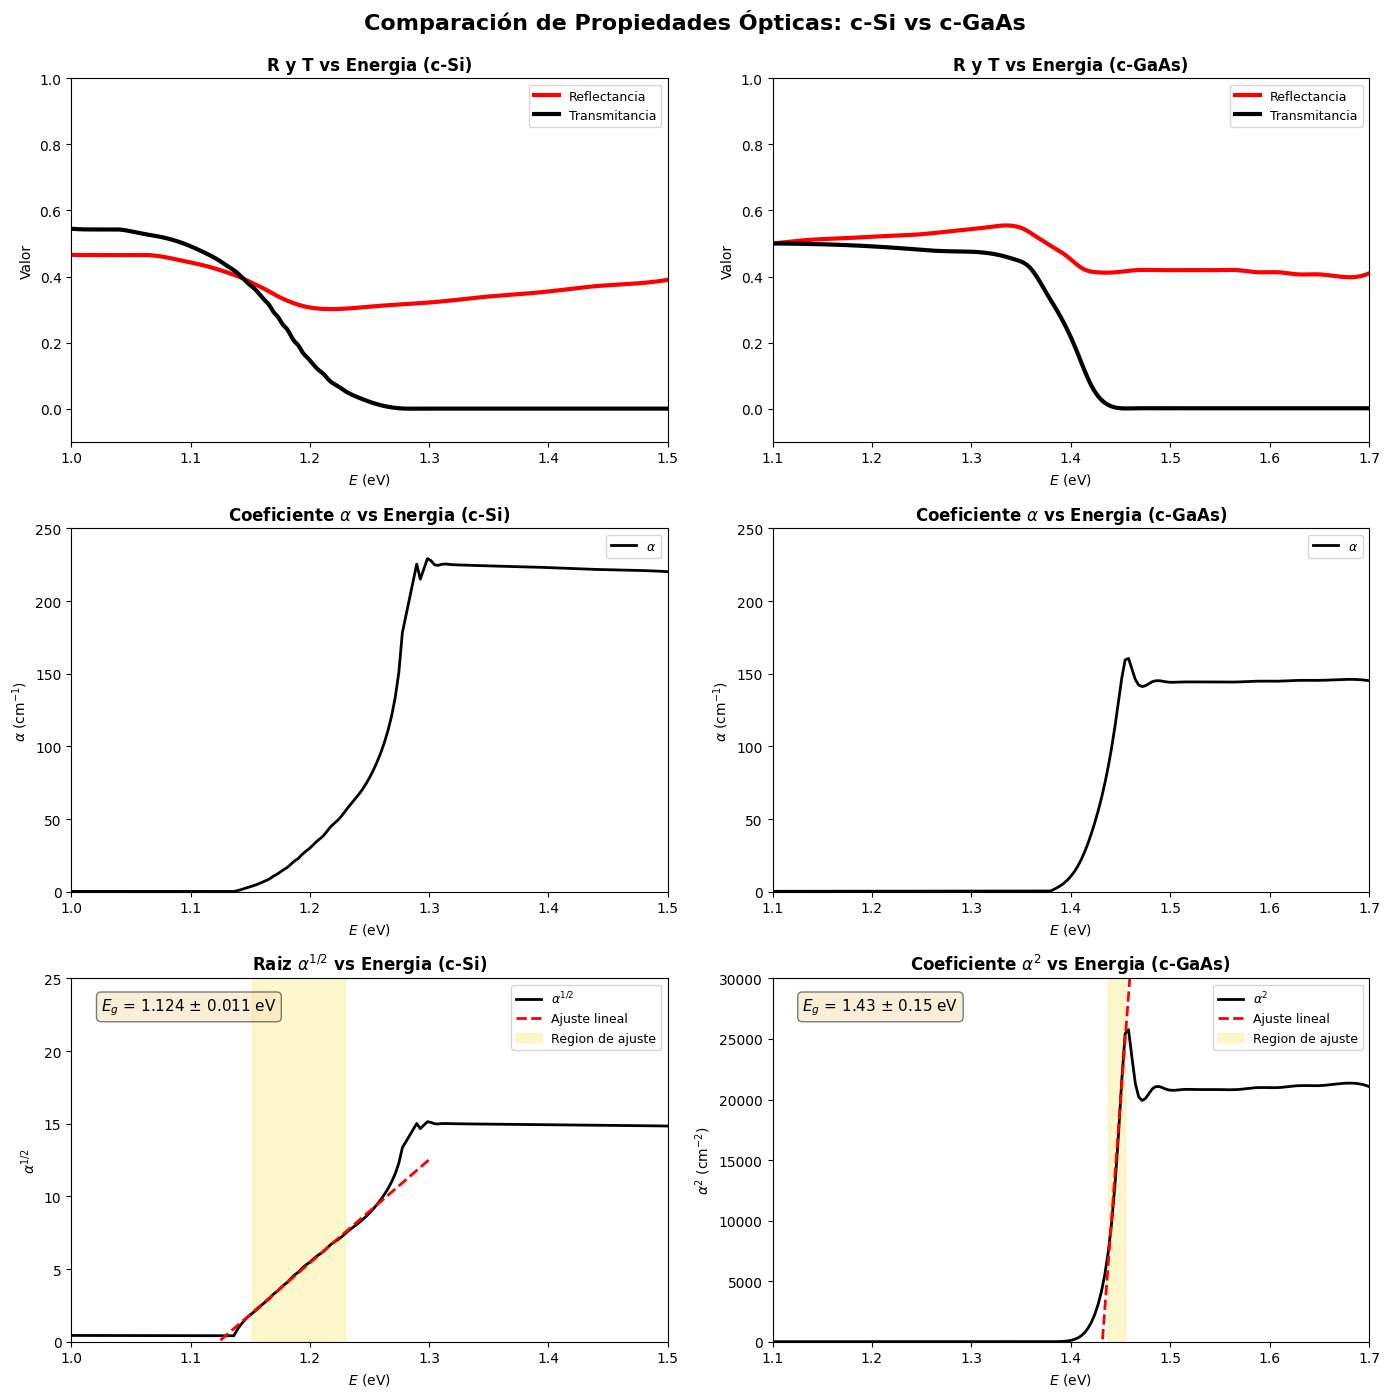

Figura guardada en: /home/edgar/GitHub/Proyectos/Proyectos_python/FISICA/Optica/Poster/comparacion_optica_si_gaas.png


In [77]:
Eg_si = -b / m
Eg_gaas = -b_gaas / m_gaas

# Tomar errores calculados en la celda de propagacion (si existen)
err_plot_si = err_Eg_si if 'err_Eg_si' in globals() else np.nan
err_plot_gaas = err_Eg_gaas if 'err_Eg_gaas' in globals() else np.nan

# Limites de las regiones de ajuste lineal (si existen en el entorno, se usan esas)
if 'x_regresion' in globals() and len(x_regresion) > 0:
    xfit_si_min, xfit_si_max = float(np.min(x_regresion)), float(np.max(x_regresion))
else:
    xfit_si_min, xfit_si_max = 1.15, 1.23

if 'x_regresion_gaas' in globals() and len(x_regresion_gaas) > 0:
    xfit_gaas_min, xfit_gaas_max = float(np.min(x_regresion_gaas)), float(np.max(x_regresion_gaas))
else:
    xfit_gaas_min, xfit_gaas_max = 1.436, 1.456

fig, ax = plt.subplots(3, 2, figsize=(14, 14))

fig.suptitle('Comparación de Propiedades Ópticas: c-Si vs c-GaAs', fontsize=16, fontweight='bold', y=0.995)

# ==================== COLUMNA IZQUIERDA: SILICIO ====================

# (0,0) REFLECTANCIA Y TRANSMITANCIA (c-Si)
ax[0, 0].plot(mallado, Reflectancia(mallado), 'r-', linewidth=3, label='Reflectancia')
ax[0, 0].plot(mallado, Transmitancia(mallado), 'k-', linewidth=3, label='Transmitancia')
ax[0, 0].set_xlabel(r'$E$ (eV)')
ax[0, 0].set_ylabel('Valor')
ax[0, 0].set_title('R y T vs Energia (c-Si)', fontweight='bold')
ax[0, 0].legend(fontsize=9)
ax[0, 0].set_xlim(1, 1.5)
ax[0, 0].set_ylim(-0.1, 1)


# (1,0) COEFICIENTE DE ABSORCION ALPHA (c-Si)
ax[1, 0].plot(mallado_1, alpha_values1, 'k-', linewidth=2, label=r'$\alpha$')
ax[1, 0].set_xlabel(r'$E$ (eV)')
ax[1, 0].set_ylabel(r'$\alpha$ (cm$^{-1}$)')
ax[1, 0].set_title(r'Coeficiente $\alpha$ vs Energia (c-Si)', fontweight='bold')
ax[1, 0].legend(fontsize=9)
ax[1, 0].set_xlim(1, 1.5)
ax[1, 0].set_ylim(0, 250)


# (2,0) RAIZ DEL COEFICIENTE CON AJUSTE LINEAL (c-Si)
ax[2, 0].plot(mallado_1, alpha_values_1_2, 'k-', linewidth=2, label=r'$\alpha^{1/2}$')
x_recta_si = np.array([1, 1.30])
y_recta_si = m * x_recta_si + b
ax[2, 0].plot(x_recta_si, y_recta_si, 'r--', linewidth=2, label='Ajuste lineal')
ax[2, 0].axvspan(xfit_si_min, xfit_si_max, color='gold', alpha=0.2, label='Region de ajuste')
ax[2, 0].set_xlabel(r'$E$ (eV)')
ax[2, 0].set_ylabel(r'$\alpha^{1/2}$')
ax[2, 0].set_title(r'Raiz $\alpha^{1/2}$ vs Energia (c-Si)', fontweight='bold')
ax[2, 0].legend(fontsize=9)
ax[2, 0].set_xlim(1, 1.5)
ax[2, 0].set_ylim(0, 25)
ax[2, 0].text(
    0.05,
    0.95,
    f'$E_g$ = {Eg_si:.3f} ± {err_plot_si:.3f} eV',
    transform=ax[2, 0].transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)


# ==================== COLUMNA DERECHA: GaAs ====================

# (0,1) REFLECTANCIA Y TRANSMITANCIA (c-GaAs)
ax[0, 1].plot(x_malla_extendida, spline_roja(x_malla_extendida), 'r-', linewidth=3, label='Reflectancia')
ax[0, 1].plot(x_malla_extendida, spline_negra(x_malla_extendida), 'k-', linewidth=3, label='Transmitancia')
ax[0, 1].set_xlabel(r'$E$ (eV)')
ax[0, 1].set_ylabel('Valor')
ax[0, 1].set_title('R y T vs Energia (c-GaAs)', fontweight='bold')
ax[0, 1].legend(fontsize=9)
ax[0, 1].set_xlim(1.1, 1.7)
ax[0, 1].set_ylim(-0.1, 1)


# (1,1) COEFICIENTE DE ABSORCION ALPHA (c-GaAs)
ax[1, 1].plot(malla_gaas, alpha_values1_gaas, 'k-', linewidth=2, label=r'$\alpha$')
ax[1, 1].set_xlabel(r'$E$ (eV)')
ax[1, 1].set_ylabel(r'$\alpha$ (cm$^{-1}$)')
ax[1, 1].set_title(r'Coeficiente $\alpha$ vs Energia (c-GaAs)', fontweight='bold')
ax[1, 1].legend(fontsize=9)
ax[1, 1].set_xlim(1.1, 1.7)
ax[1, 1].set_ylim(0, 250)


# (2,1) CUADRADO DEL COEFICIENTE CON AJUSTE LINEAL (c-GaAs)
ax[2, 1].plot(malla_gaas, alpha_values_2_gaas, 'k-', linewidth=2, label=r'$\alpha^2$')
x_recta_gaas = np.array([1.3, 1.5])
y_recta_gaas = m_gaas * x_recta_gaas + b_gaas
ax[2, 1].plot(x_recta_gaas, y_recta_gaas, 'r--', linewidth=2, label='Ajuste lineal')
ax[2, 1].axvspan(xfit_gaas_min, xfit_gaas_max, color='gold', alpha=0.2, label='Region de ajuste')
ax[2, 1].set_xlabel(r'$E$ (eV)')
ax[2, 1].set_ylabel(r'$\alpha^2$ (cm$^{-2}$)')
ax[2, 1].set_title(r'Coeficiente $\alpha^2$ vs Energia (c-GaAs)', fontweight='bold')
ax[2, 1].legend(fontsize=9)
ax[2, 1].set_xlim(1.1, 1.7)
ax[2, 1].set_ylim(0, 3e4)
ax[2, 1].text(
    0.05,
    0.95,
    f'$E_g$ = {Eg_gaas:.2f} ± {err_plot_gaas:.2f} eV',
    transform=ax[2, 1].transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

plt.tight_layout()
plt.show()

# Guardar en el mismo directorio de trabajo donde ejecutas el notebook/codigo
from pathlib import Path
ruta_salida = Path.cwd() / 'comparacion_optica_si_gaas.png'
fig.savefig(ruta_salida, dpi=300, bbox_inches='tight')
print(f'Figura guardada en: {ruta_salida}')

In [67]:
import numpy as np
from scipy.optimize import curve_fit

# --- 1. FUNCIONES DE ERROR ---
def error_alpha(R, T, d, err_R, err_T, err_d):
    eps = 1e-7
    def a_base(r, t, d_val):
        return (1/d_val) * np.log((1-r)**2 / (2*t) + np.sqrt(((1-r)**4 / (4*t**2)) + r**2))
    
    da_dR = (a_base(R+eps, T, d) - a_base(R-eps, T, d)) / (2*eps)
    da_dT = (a_base(R, T+eps, d) - a_base(R, T-eps, d)) / (2*eps)
    da_dd = (a_base(R, T, d+eps) - a_base(R, T, d-eps)) / (2*eps)
    
    return np.sqrt((da_dR * err_R)**2 + (da_dT * err_T)**2 + (da_dd * err_d)**2)

def error_eje_y(alpha, err_alpha, tipo):
    if tipo == "indirecto": return 0.5 * (1 / np.sqrt(alpha)) * err_alpha
    elif tipo == "directo": return 2 * alpha * err_alpha

def funcion_lineal(x, m, b):
    return m * x + b

# --- 2. CÁLCULO PARA SILICIO (c-Si) ---
# Sustituye 'espesor_si' por tu variable real en cm.
# Define el rango lineal donde haces el ajuste (ejemplo: de 1.1 a 1.25 eV)
mascara_si = (mallado_1 >= 1.15) & (mallado_1 <= 1.23) 
E_fit_si = mallado_1[mascara_si]
R_fit_si = Reflectancia(E_fit_si)
T_fit_si = Transmitancia(E_fit_si)
alpha_fit_si = alpha_values1[mascara_si]

err_alpha_si = error_alpha(R_fit_si, T_fit_si, d, err_R=0.0043, err_T=0.0043, err_d=5e-4)
err_y_si = error_eje_y(alpha_fit_si, err_alpha_si, tipo="indirecto")
y_data_si = np.sqrt(alpha_fit_si)

popt_si, pcov_si = curve_fit(funcion_lineal, E_fit_si, y_data_si, sigma=err_y_si, absolute_sigma=False)
m, b = popt_si
err_m_si, err_b_si = np.sqrt(np.diag(pcov_si))

Eg_si = -b / m
err_Eg_si = np.sqrt((err_b_si / m)**2 + (b * err_m_si / (m**2))**2)

# --- 3. CÁLCULO PARA ARSENIURO DE GALIO (c-GaAs) ---
# Sustituye 'espesor_gaas' por tu variable real en cm.
# Define el rango lineal donde haces el ajuste (ejemplo: de 1.38 a 1.45 eV)
mascara_gaas = (malla_gaas >= 1.436) & (malla_gaas <= 1.456)
E_fit_gaas = malla_gaas[mascara_gaas]
R_fit_gaas = spline_roja(E_fit_gaas)
T_fit_gaas = spline_negra(E_fit_gaas)
alpha_fit_gaas = alpha_values1_gaas[mascara_gaas]

err_alpha_gaas = error_alpha(R_fit_gaas, T_fit_gaas, d_gaas, err_R=0.00644, err_T=0.00644, err_d=5e-4)
err_y_gaas = error_eje_y(alpha_fit_gaas, err_alpha_gaas, tipo="directo")
y_data_gaas = alpha_fit_gaas**2

popt_gaas, pcov_gaas = curve_fit(funcion_lineal, E_fit_gaas, y_data_gaas, sigma=err_y_gaas, absolute_sigma=False)
m_gaas, b_gaas = popt_gaas
err_m_gaas, err_b_gaas = np.sqrt(np.diag(pcov_gaas))

Eg_gaas = -b_gaas / m_gaas
err_Eg_gaas = np.sqrt((err_b_gaas / m_gaas)**2 + (b_gaas * err_m_gaas / (m_gaas**2))**2)

print(f"c-Si: Eg = {Eg_si:.3f} ± {err_Eg_si:.3f} eV")
print(f"c-GaAs: Eg = {Eg_gaas:.3f} ± {err_Eg_gaas:.3f} eV")

c-Si: Eg = 1.124 ± 0.011 eV
c-GaAs: Eg = 1.429 ± 0.146 eV
